# Regression task

https://web.stanford.edu/~mrosenfe/soc_meth_proj3/matrix_OLS_NYU_notes.pdf

In [1]:
# Loading data 
from pandas import read_csv

# Numerical computing
import numpy as np

# Statistical functions
from scipy import stats

# Regression task
from sklearn.base import BaseEstimator

# Printing the reports
from tabulate import tabulate

# Data visualization
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
font = {
    'family': 'arial',
    'size': 12,
    'weight': 'bold'
}

plt.rc('font', **font)

In [5]:
import warnings

warnings.filterwarnings('ignore')

We define an user defined class to print the algorithm outcomes 

In [7]:
class PrintReport:

    def __init__(self):
        pass

    def print_coeff(self, data: dict):
        print('\033[1mEstimated coefficients\033[0m \n')
        coeff_ = {k: f'{v:.5f}' for k,v in zip([f'b{i}' for i in range(len(data))], data)}
        report = tabulate(
            tabular_data=[[f'{v}' for v in coeff_.values()]],
            headers=[f'\033[1m{k}\033[0m' for k in coeff_.keys()],
            colalign=tuple('right' for _ in range(len(data))),
            tablefmt='pipe'
        )
        return print(report)

    def print_row(self, data: list):
        row = tabulate(
            tabular_data=[data], 
            tablefmt='pipe', colalign=('right', 'right')
        )
        return print(row)

## Closed form solution

We consider the following linear model:

$$ \mathbf{y} = \mathbf{X}b + e $$

where:
- $ \mathbf{y} $ is an $ n \times 1 $ vector of the dependent variable $ y_i $
- $ \mathbf{X} $ is an $ n \times 2 $ matrix (1st column of ones for the intercept, 2nd column for the independent variable $ x_i $)
- $ b $ is a $ 2 \times 1 $ vector containing the parameters (intercept $ b_0 $ and slope $ b_1 $)
- $ e $ is an $ n \times 1 $ vector of residuals $ e_i $

&nbsp;

$$ \begin{bmatrix} y_1 \\ y_2 \\ \vdots \\ y_n \end{bmatrix} = \begin{bmatrix} 1 & x_1 \\ 1 & x_2 \\ \vdots & \vdots \\ 1 & x_n \end{bmatrix} \begin{bmatrix} b_0 \\ b_1 \end{bmatrix} + \begin{bmatrix} e_1 \\ e_2 \\ \vdots \\ e_n \end{bmatrix} $$

### Ordinary Least Squares (OLS) estimation 

The goal of OLS is to minimize the sum of squared residuals:

$$ e^\top e = (\mathbf{y} - \mathbf{X}b)^\top(\mathbf{y} - \mathbf{X}b) = \mathbf{y}^\top\mathbf{y} - b^\top\mathbf{X}^\top\mathbf{y} - \mathbf{y}^\top\mathbf{X}b + b^\top\mathbf{X}^\top\mathbf{X}b $$

This development uses the fact that $\mathbf{y}^\top\mathbf{X}b = (\mathbf{y}^\top\mathbf{X}b)^\top = b^\top\mathbf{X}^\top\mathbf{y}$

$$ e^\top e = \mathbf{y}^\top\mathbf{y} - 2b^\top\mathbf{X}^\top\mathbf{y} + b^\top\mathbf{X}^\top\mathbf{X}b $$

To find the coefficients that minimizes the sum of squared residuals, we need to take the derivative of $e^\top e$ with respect to $b$

$$ \arg\min_{b} e^\top e = \frac{\partial}{\partial b} (\mathbf{y}^\top\mathbf{y} - 2b^\top\mathbf{X}^\top\mathbf{y} + b^\top\mathbf{X}^\top\mathbf{X}b) = 0 $$

$$ 2\mathbf{X}^\top\mathbf{X}b -2\mathbf{X}^\top\mathbf{y} = 0 $$

$$ \mathbf{X}^\top\mathbf{X}b = \mathbf{X}^\top\mathbf{y} $$

If the inverse of $\mathbf{X}^\top\mathbf{X}$ exists, then pre-multiplyng both sides by the inverse gives us the following equation:

$$ (\mathbf{X}^\top\mathbf{X})^{-1}\mathbf{X}^\top\mathbf{X}b = (\mathbf{X}^\top\mathbf{X})^{-1}\mathbf{X}^\top\mathbf{y} $$

We know that $(\mathbf{X}^\top\mathbf{X})^{-1} \mathbf{X}^\top\mathbf{X} = \mathbf{I}$ identity matrix. This gives us:

$$ \hat{b}_{OLS} = (\mathbf{X}^\top\mathbf{X})^{-1}\mathbf{X}^\top\mathbf{y} $$

In [9]:
class LinearRegressionOLS(BaseEstimator):

    def __init__(self):
        # Initialize theta as None
        self.theta = None

    def add_constant(self, X):
        """Add bias term (constant column of ones) to X."""
        return np.c_[np.ones((len(X), 1)), X]

    def fit(self, X, y=None):
        """Fit the model to the data using the Normal Equation."""
        # Add bias term
        X_b = self.add_constant(X)
        # Use the pseudo-inverse for a more numerically stable solution
        self.theta = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)
        return self

    def predict(self, x):
        """Make predictions for new data."""
        X_new = np.array([[x]])
        # Add bias term
        X_new_b = self.add_constant(X_new)
        return X_new_b.dot(self.theta)

    def weights(self):
        """Return the model weights (theta)."""
        return self.theta

    def r_squared(self):
        """Compute the R^2 score."""
        # Add bias term
        X_b = self.add_constant(X)
        # Make predictions
        y_pred = X_b.dot(self.theta)
        # Total Sum of Squares
        ss_tot = (y-np.mean(y)).T.dot((y-np.mean(y)))
        # Residual Sum of Squares
        ss_res = (y-y_pred).T.dot((y-y_pred))
        return 1 - (ss_res/ss_tot)

    def residuals(self):
        """Compute the residuals (difference between true and predicted values)."""
        X_b = self.add_constant(X)
        # Make predictions
        y_pred = X_b.dot(self.theta)
        return (y-y_pred)

## Loading dataset

In [46]:
sales = read_csv('input/advertising.csv')
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


## Understanding the relationship between variables

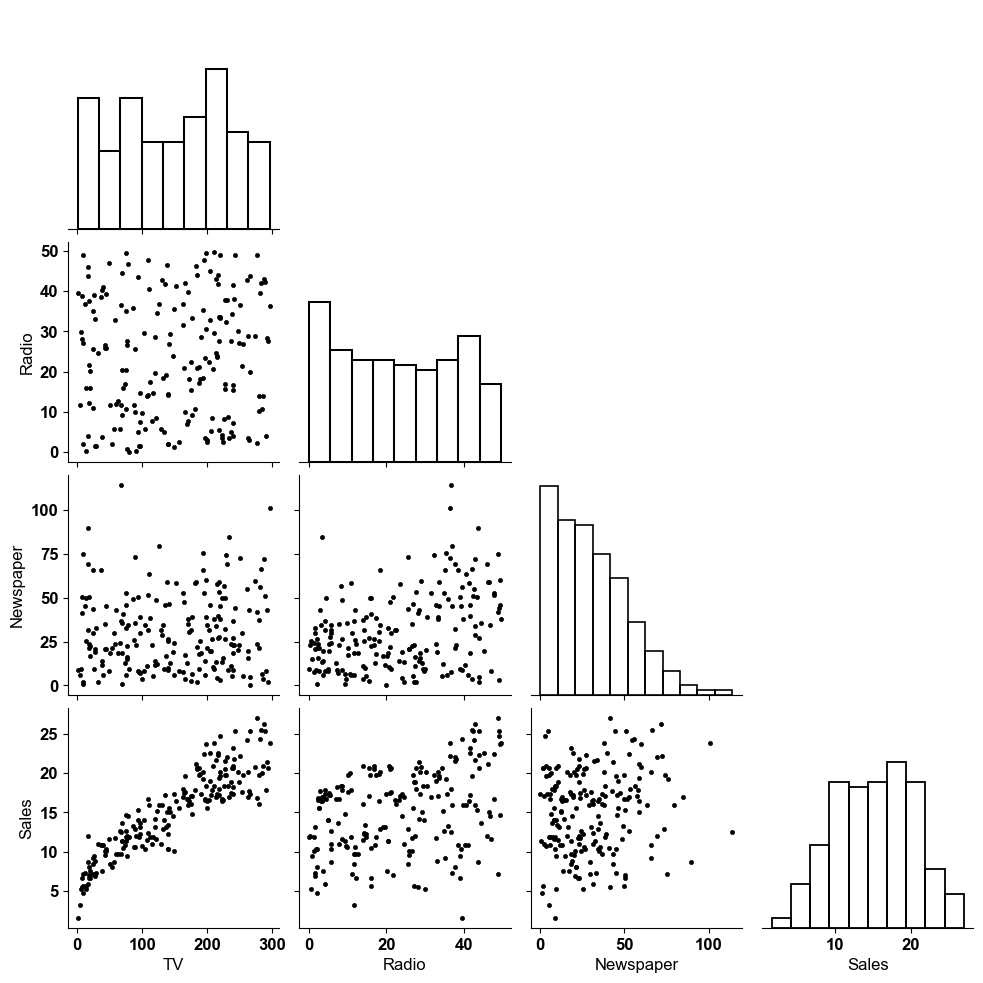

In [48]:
sns.pairplot(
    sales, 
    corner=True, 
    diag_kws={'fill': 0, 'color': 'black',},
    plot_kws={'edgecolor': 'black', 'facecolor': 'black', 'marker': '.'}
);

Seems to be a linear relationship between TV advertising spending and sales. As spending increases, sales also increase in a linear way.

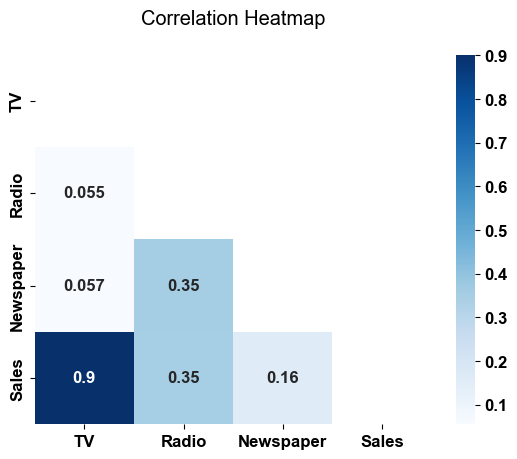

In [50]:
corr = sales.select_dtypes(include=[np.number]).corr()

# Getting the Upper Triangle of the co-relation matrix
diag = np.triu(corr)

sns.heatmap(corr, annot=True, mask=diag, cmap='Blues')
plt.title('Correlation Heatmap\n');

The Pearson correlation coefficient ($\rho \approx .9$) suggests a strong linear correlation between TV advertising spending and sales.

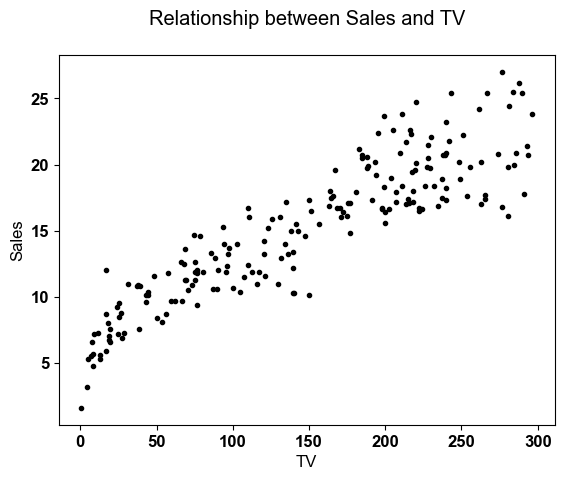

In [52]:
plt.scatter(x=sales['TV'], y=sales['Sales'], color='k', marker='.')
plt.xlabel('TV')
plt.ylabel('Sales')
plt.title('Relationship between Sales and TV\n');

Once the linear relationship between our variables is confirmed, we can proceed with fitting a simple linear regression model using TV advertising spending as the explanatory variable and sales as the output variable.

## Solving the OLS in closed form

We will use the `LinearRegressionOLS()` class defined above to fit our regression model.

$$ \textbf{y} = \textbf{X}b + e $$

In [19]:
X, y = sales['TV'].values, sales['Sales'].values

In [21]:
lin_reg_cf = LinearRegressionOLS()
lin_reg_cf.fit(X, y)

LinearRegressionOLS()

$$ \hat{b}_{OLS} = (\textbf{X}^T\textbf{X})^{-1}\textbf{X}^T\textbf{y} $$

where $ (\textbf{X}^T\textbf{X})^{-1} $ is the variance-covariance matrix. 

In [23]:
coeff = lin_reg_cf.weights()
PrintReport().print_coeff(data=coeff)

Estimated coefficients 

|      b0 |      b1 |
|--------:|--------:|
| 6.97482 | 0.05546 |


The fitted regression equation is: 

$$ \text{Sales} = 6.97482 + 0.05546 \times \text{(TV advertising spending)} $$ 

This means that every additional cost spent on advertising is associated with an increase in average sales of 0.05546 units. The value of 6.97482 tells us the expected average sales for zero advertising spending.

We can use this equation to find the expected sales based on TV advertising spending values. For example, a spending of 305 thousand dollars should produce sales of about 23.89 thousand dollars:

$$ \text{Sales} = 6.97482 + 0.05546 \times (305) \approx 23.89 $$ 

In [25]:
lin_reg_cf.predict(305)

array([23.89157648])

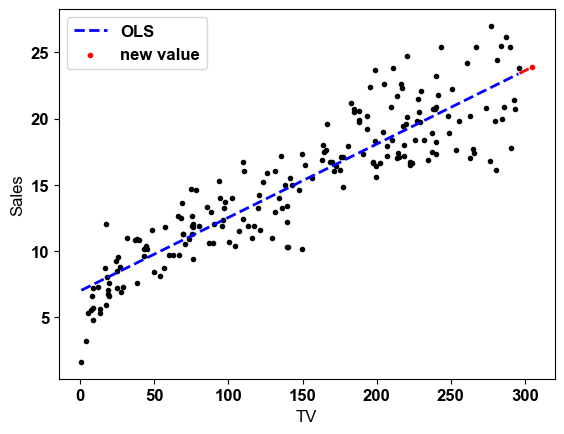

In [27]:
ax_x = np.arange(min(X), max(X), 1)
x = 305
ax_x_new = np.arange(max(X), x, 1)
b_0, b_1 = lin_reg_cf.weights()

plt.scatter(X, y, color='k', marker='.')
plt.plot(ax_x, b_0 + b_1*ax_x, 'b--', lw=2, label='OLS')
plt.plot(ax_x_new, b_0 + b_1*ax_x_new, 'r--', lw=2)
plt.scatter(x, lin_reg_cf.predict(x), color='r', marker='.', label='new value')
plt.xlabel('TV')
plt.ylabel('Sales')
plt.legend();

## Evaluating model performance

**R-squared** tells us the percentage of variation in sales explained by TV advertising spending. The higher the R-squared value of the model, the better the explanatory variables are at predicting the value of the response variable. 

$$ R^2 = 1 - \frac{(\mathbf{y} - \hat{\mathbf{y}})^\top (\mathbf{y} - \hat{\mathbf{y}})} {(\mathbf{y} - \mathbf{1}_n \bar{\mathbf{y}})^\top (\mathbf{y} - \mathbf{1}_n \bar{\mathbf{y}})} $$

where:
- $ \mathbf{y} $ is the vector of observed values
- $ \hat{\mathbf{y}} $ is the vector of predicted values
- $ \bar{y} $ is the mean of $ \mathbf{y} $
- $ \mathbf{1}_n $ is a column vector of dimension $ n \times 1 $ filled with ones.

In [29]:
print(f'\033[1mR-squared\033[0m = {lin_reg_cf.r_squared():.4f}')

R-squared = 0.8122


In this case, 81.2% of the variation in sales is explained by TV advertising spending.

## Residuals analysis

In [31]:
import statsmodels.api as sm

In [33]:
# aggiunta termine costante
X_ = sm.add_constant(X)
# adattamento retta di regressione
model = sm.OLS(y, X_).fit()
# riepilogo dei risultati del modello
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.812
Model:                            OLS   Adj. R-squared:                  0.811
Method:                 Least Squares   F-statistic:                     856.2
Date:                Sun, 05 Jan 2025   Prob (F-statistic):           7.93e-74
Time:                        18:24:35   Log-Likelihood:                -448.99
No. Observations:                 200   AIC:                             902.0
Df Residuals:                     198   BIC:                             908.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          6.9748      0.323     21.624      0.0

In [35]:
u = model.resid
np.mean(u)

-1.1013412404281553e-15

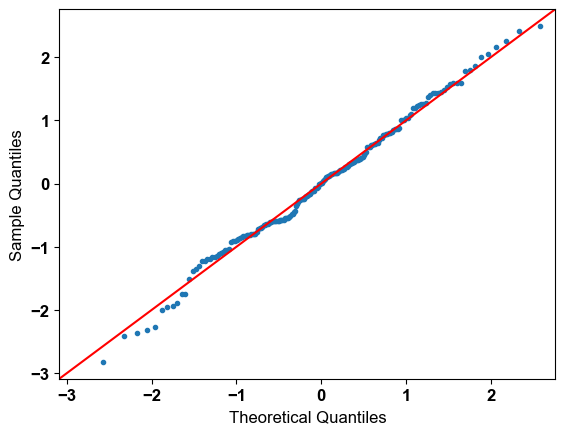

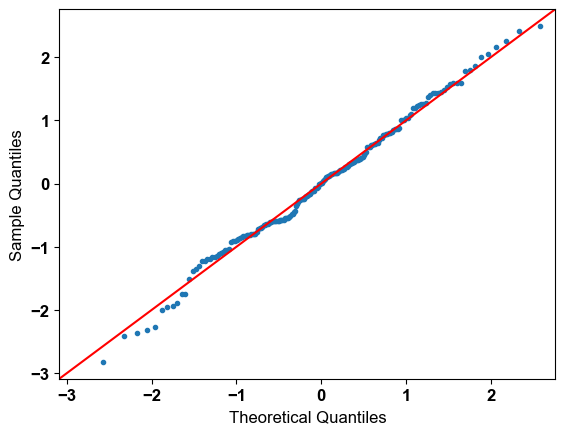

In [37]:
sm.qqplot(u, fit=True, line='45', marker='.')

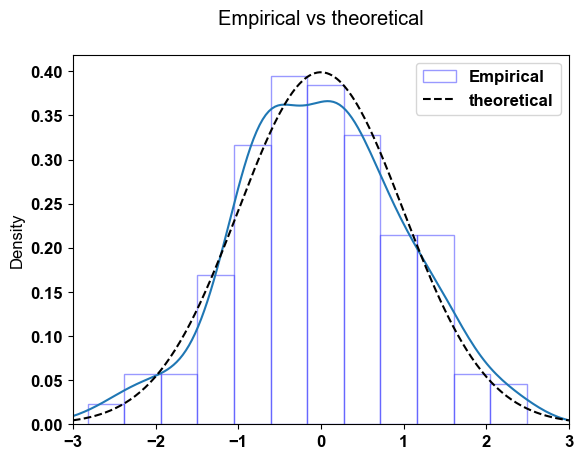

In [126]:
z = (u - np.mean(u))/np.var(u)**.5
sns.distplot(z, kde=True, 
             hist_kws=dict(edgecolor='blue', color='white'), 
             label='Empirical')
ax_x = np.linspace(-3, +3, len(u))
plt.plot(ax_x, ((2*np.pi)**-.5)*np.exp(-.5*(ax_x**2)), 'k--', label='theoretical')
plt.title('Empirical vs theoretical\n')
plt.xlim(-3, +3)
plt.legend();

In [49]:
np.corrcoef(X, u)

array([[1.00000000e+00, 2.83811347e-16],
       [2.83811347e-16, 1.00000000e+00]])

One of the basic assumptions of linear regression is that the residuals of a regression model are approximately normally distributed with zero mean ($ \mathbf{E}[e_i]=0 $) and homoscedastic ($ \mathbf{Var}(e_i)=\sigma^2 $) at each level of the explanatory variable. If these assumptions are not met, the results of our regression model could be misleading or unreliable.

In [310]:
print(
    all([(round(i, 10) == round(j, 10)) for (i, j) in zip(u, lin_reg_cf.residuals())]),
    all([(round(i, 10) == round(j, 10)) for (i, j) in zip(
        model.fittedvalues, 
        np.array([lin_reg_cf.predict(x)[0] for x in X])
    )])
)

True True


In [31]:
residuals = lin_reg_cf.residuals()
residuals.mean()

-1.3162804179955856e-14

To check if these assumptions are met, we can create the following residual plots.

&nbsp;

##### 1. Residuals plot versus the fitted values
This plot is useful to confirm homoscedasticity. The x-axis shows the fitted values and the y-axis shows the residuals. As long as the residuals appear randomly and evenly distributed around zero across the plot, we can assume that homoscedasticity is not violated.

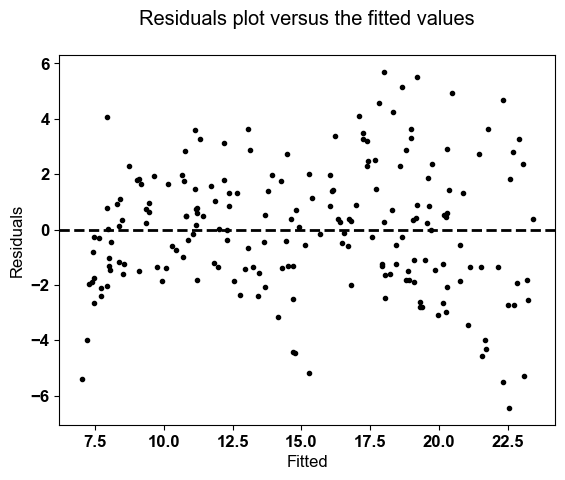

In [33]:
fitted = np.array([lin_reg_cf.predict(x)[0] for x in X])

# Create the residuals plot
plt.title('Residuals plot versus the fitted values\n')
plt.scatter(fitted, residuals, color='k', marker='.')
plt.axhline(residuals.mean(), color='k', linestyle='--', lw=2)
plt.xlabel('Fitted')
plt.ylabel('Residuals')
plt.show()

Since the residuals appear to be randomly spread around zero, this suggests that heteroscedasticity is not an issue with the explanatory variable.

&nbsp;

##### 2. Q-Q plot
This plot is useful to determine if the residuals follow a normal distribution. If the data points in the plot follow a roughly straight line at a 45-degree angle, the data is normally distributed.

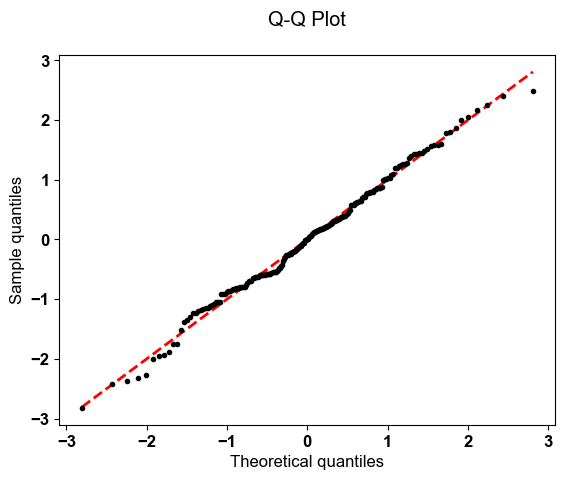

In [35]:
# [(round(i,9) == round(j,9)) for (i,j) in zip(u, lin_reg_cf.residuals())]
residuals = lin_reg_cf.residuals()
# Standardise and sort the residuals
sorted_residuals = np.sort((residuals - np.mean(residuals)) / np.std(residuals))

# Calculate the quantiles of the theoretical normal distribution
theoretical_quantiles = stats.norm.ppf(
    (np.arange(1, len(sorted_residuals) + 1) - 0.5) / len(sorted_residuals)
)

# Create the Q-Q plot
plt.scatter(theoretical_quantiles, sorted_residuals, color='k', marker='.', zorder=1)
# Add the reference line (y=x line) for comparison
plt.plot(theoretical_quantiles, theoretical_quantiles, 'r--', lw=2, zorder=0)
# Labels and title
plt.title('Q-Q Plot\n')
plt.xlabel('Theoretical quantiles')
plt.ylabel('Sample quantiles');

The residuals slightly deviate from the 45-degree line, but not enough to raise serious concern. We can assume that the normality assumption is met.

Furthermore, the independent variable should not be correlated with the error term. This means that regressor must be exogenous, i.e. any variation in it is unrelated to the errors:

$$ \mathbf{Cov}(X_i,e_j)=0 $$

In [37]:
np.fliplr(np.corrcoef(X, residuals))[0][0]

7.864091211939043e-16

Finally, the residuals should be not autocorrelated, i.e. the errors in the predictions of a model are independent of each other. In other words, one error should not provide information about another. This is important because the presence of autocorrelation suggests that the model has not captured all the patterns in the data, leading to potentially biased or unreliable results.

To check for the presence of autocorrelation in the residuals, we can use the **Durbin-Watson test**:

$$ DW = \frac{\sum_{i=2}^{n} (e_i - e_{i-1})^2}{\sum_{i=1}^{n} e_i^2} $$

The test statistic is approximately equal to 2 ($ DW \approx 2 $), indicating no serial correlation. This statistic will always be between 0 and 4: the closer to 0 the statistic, the more evidence for positive serial correlation; the closer to 4, the more evidence for negative serial correlation.

In [39]:
from statsmodels.stats.stattools import durbin_watson

# Compute Durbin-Watson statistic
durbin_watson(residuals)

2.029436406711659

In our case, DW it's very close to 2, which suggests no significant autocorrelation. This means that the residuals are independent, without any major autocorrelation problems.

Since the residuals are homoscedastic, not autocorrelated, and not correlated with the independent variable, we have verified that the Gauss-Markov assumptions for the simple linear regression model are met. While the residuals being normally distributed is not a requirement for the Gauss-Markov theorem, it is important for certain hypothesis tests. Therefore, our model seems to fit the data well, and the output of our model is reliable.

## Gradient descent approach

We will define a linear relationship between $y$ (dependent variable) and $x$ (independent variable) as follows:

$$ y = h_b(x) + e $$

where:
- $h_b(x) = b_0 + b_1x$ is the hypothesis function
- $e$ is the error term.

We will use this equation to train our model with a given dataset and predict the value of $y$ for any given value of $x$. Our goal is to determine the value of $b_0$ and $b_1$, such that the line corresponding to those values is the best fitting line or gives the minimum error.

### Loss Function 

Our goal is to minimize this error to obtain the most accurate value of $b_0$ and $b_1$. We will use the Mean Squared Error to calculate the Loss function.

$$ L(b_0,b_1) \coloneqq \frac{1}{n}\sum_{i=1}^n e_i^2 = \frac{1}{n} \sum_{i=1}^n {\left(y_i - h_b(x_i)\right)^2} $$

where $n$ is the number of training examples.

### The Gradient descent algorithm

Gradient descent is an iterative optimization algorithm to find the minimum of a function. Here that is Loss Function. Let’s apply gradient descent algorithm to coefficients $ b_0 $ and $ b_1 $ and approach it step by step:

- Initially instantiate $ b_0 = 0 $ and $ b_1 = 0 $. Let $ a $ be our learning rate. This controls how much the value of $ b_1 $ changes with each step. The learning rate could be a small value (g.e. $ a = 0.00003) $ for good accuracy.
- Calculate the partial derivative of the loss function with respect to $ b_1 $, and plug in the current values of $ x $, $ y $, $ b_1 $ and $ b_0 $ in it to obtain the derivative value.

  $$ D_{b_0} = -\frac{2}{n} \sum_{i=1}^n {\left(y_i - h_b(x_i)\right)} $$

  $ D_{b_0} $ is the value of the partial derivative with respect to $ b_0 $. Similarly lets find the partial derivative with respect to $ b_1 $:

  $$ D_{b_1} = -\frac{2}{n} \sum_{i=1}^n {\left(y_i - h_b(x_i)\right)x_i} $$

- We update the current value of b0 and b1 using the following equations:

  $$ b_0 = b_0 - aD_{b_0} $$
  $$ b_1 = b_1 - aD_{b_1} $$

- We repeat this process until our loss function is a very small value (ideally 0, which means 0 error or 100% accuracy). The obtained value of $ b_0 $ and $ b_1 $ will be the optimum values.

### Implementing the Model

In [41]:
class LinearRegression_GD:

    def __init__(self):
        pass

    def predict(self, X, y, learning_rate, n_epochs):
        # Initialize coefficients
        b_0, b_1 = 0, 0

        # Instantiate report
        report= PrintReport()
        report.print_row(data=['\033[1mn. epochs\033[0m', '\033[1mloss v.\033[0m'])

        # Performing Gradient Descent
        loss_values = []
        for epoch in range(n_epochs): 
            # The current predicted value of y
            y_pred = b_0 + b_1*X  
          
            # Derivative wrt b_0
            D_b_0 = (-2/len(X)) * sum(y - y_pred) 
            # Derivative with respect to b_1
            D_b_1 = (-2/len(X)) * sum((y - y_pred)*X)
            # Update b_0
            b_0 -= learning_rate * D_b_0
            # Update b_1
            b_1 -= learning_rate * D_b_1  
            
            # Loss function: Mean Squared Error (MSE) 
            mse = 1/len(X) * np.sum((y - y_pred)**2)
            if (epoch + 1) % 10000 == 0:
                report.print_row(data=[f'{epoch + 1}\nof {n_epochs}',
                                       f'≈      \n{mse:.4f}'])
                loss_values.append(mse)

        return np.array([b_0, b_1]), loss_values

    def r_squared(self, b):
        # Compute predictions
        y_pred = b[0] + b[1]*X
        # Compute R squared
        return 1 - (np.sum((y - y_pred)**2) \
                    / np.sum((y - np.mean(y))**2))

In [388]:
model = LinearRegression_GD()
coeff, losses = model.predict(X=X, y=y, learning_rate=.00003, n_epochs=100_000)

|----------:|--------:|
| n. epochs | loss v. |
|----------:|--------:|
|     10000 | ≈       |
| of 100000 | 14.3093 |
|----------:|--------:|
|     20000 | ≈       |
| of 100000 | 11.9264 |
|----------:|--------:|
|     30000 | ≈       |
| of 100000 | 10.1681 |
|----------:|--------:|
|     40000 | ≈       |
| of 100000 |  8.8707 |
|----------:|--------:|
|     50000 | ≈       |
| of 100000 |  7.9132 |
|----------:|--------:|
|     60000 | ≈       |
| of 100000 |  7.2068 |
|----------:|--------:|
|     70000 | ≈       |
| of 100000 |  6.6855 |
|----------:|--------:|
|     80000 | ≈       |
| of 100000 |  6.3008 |
|----------:|--------:|
|     90000 | ≈       |
| of 100000 |  6.0169 |
|----------:|--------:|
|    100000 | ≈       |
| of 100000 |  5.8075 |


### Stochastic Gradient Descent (SGD)

In [298]:
class LinearRegression_SGD:

    def __init__(self):
        pass

    def predict(self, X, y, learning_rate, n_epochs):
        # initialize coefficients
        theta_0, theta_1 = 0, 0

        # instantiate report
        report= PrintReport()
        report.print_row(data=['\033[1mn. epochs\033[0m', '\033[1mloss v.\033[0m'])

        # performing Gradient Descent
        loss_values = []
        for epoch in range(n_epochs):
            # select a random data point
            random_index = np.random.randint(m)
            xi = X.reshape(len(X),1)[random_index:random_index+1]
            yi = y.reshape(len(y),1)[random_index:random_index+1]
            
            # make prediction
            y_pred = theta_0 + theta_1 * xi
            
            # compute gradients
            gradient_t0 = -2 * (yi - y_pred)
            gradient_t1 = -2 * (yi - y_pred)*xi
            
            # update parameters
            theta_0 -= alpha * gradient_t0
            theta_1 -= alpha * gradient_t1  
            
            # cost function: Mean Squared Error (MSE) 
            mse = 1/len(X) * np.sum((y_pred - y)**2)
            if (epoch + 1) % 10000 == 0:
                report.print_row(data=[f'{epoch + 1}\nof {n_epochs}',
                                       f'≈      \n{mse:.4f}'])
            loss_values.append(mse)

        return np.c_[theta_0, theta_1].flatten(), loss_values

    def r_squared(self, thetas):
        # compute predictions
        y_pred = thetas[0] + thetas[1]*X
        # compute R squared
        return 1 - (np.sum((y - y_pred)**2) \
                    / np.sum((y - np.mean(y))**2))

In [322]:
np.random.seed(42)

model = LinearRegression_SGD()
coeff, losses = model.predict(X=X, y=y, learning_rate=.001, n_epochs=200_000)

|----------:|--------:|
| n. epochs | loss v. |
|----------:|--------:|
|     10000 | ≈       |
| of 200000 | 44.3543 |
|----------:|---------:|
|     20000 |  ≈       |
| of 200000 | 207.9404 |
|----------:|--------:|
|     30000 | ≈       |
| of 200000 | 54.6450 |
|----------:|--------:|
|     40000 | ≈       |
| of 200000 | 29.5031 |
|----------:|---------:|
|     50000 |  ≈       |
| of 200000 | 125.5338 |
|----------:|---------:|
|     60000 |  ≈       |
| of 200000 | 175.3387 |
|----------:|--------:|
|     70000 | ≈       |
| of 200000 | 94.4817 |
|----------:|---------:|
|     80000 |  ≈       |
| of 200000 | 100.9829 |
|----------:|---------:|
|     90000 |  ≈       |
| of 200000 | 186.2584 |
|----------:|---------:|
|    100000 |  ≈       |
| of 200000 | 230.0640 |
|----------:|---------:|
|    110000 |  ≈       |
| of 200000 | 125.3679 |
|----------:|--------:|
|    120000 | ≈       |
| of 200000 | 80.8093 |
|----------:|---------:|
|    130000 |  ≈       |
| of 200000 | 105

### Fit and plot losses

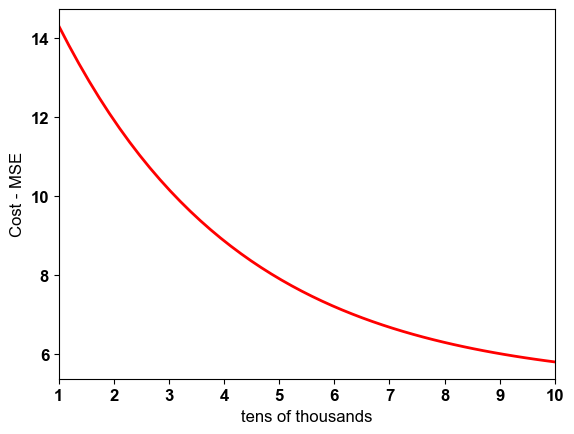

In [390]:
from scipy.interpolate import CubicSpline

# Apply cubic spline interpolation
spline = CubicSpline(np.arange(len(losses)), np.array(losses))

# Create a new array of denser values for a smoother curve
losses_fine = spline(np.linspace(0, len(losses) - 1, 50))

plt.plot(np.linspace(0, len(losses) - 1, 50), losses_fine, 'r', lw=2)
plt.xlim(1, len(losses)-1)
step = 1
if len(losses) > 10:
    step += 3
plt.xticks(np.arange(0, len(losses), step=step), np.arange(1, len(losses) + 1, step=step))
plt.xlabel('tens of thousands')
plt.ylabel('Cost - MSE');

In [165]:
np.arange(0, len(losses), 1),
np.arange(10000, (len(losses) + 1) * 10000, 10000)

array([ 10000,  20000,  30000,  40000,  50000,  60000,  70000,  80000,
        90000, 100000])

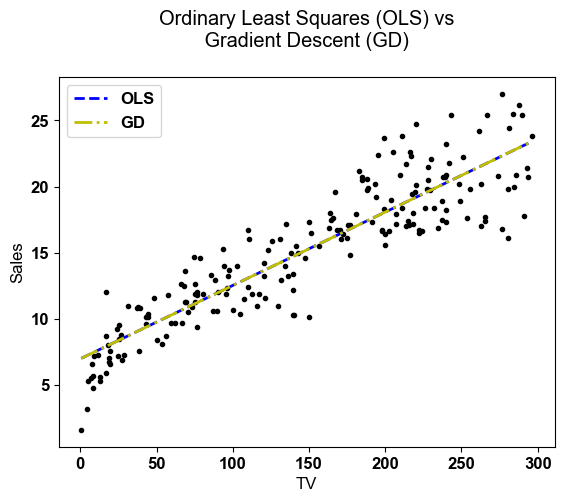

In [71]:
import matplotlib.pyplot as plt

# Making predictions
y_pred = coeff[0] + coeff[1]*X

plt.scatter(X, y, color='k', marker='.') 
plt.title("Ordinary Least Squares (OLS) vs\n Gradient Descent (GD) \n")
# regression line
plt.plot(ax_x, b_0 + b_1*ax_x, 'b--', lw=2, label='OLS')
plt.plot([min(X), max(X)], [min(y_pred), max(y_pred)], 'y-.', lw=2, label='GD')  

plt.xlabel('TV')
plt.ylabel('Sales')
plt.legend();

In [73]:
PrintReport().print_coeff(data=coeff)
print(f'\n\033[1mR-squared\033[0m = {model.r_squared(b=coeff):.4f}')

Estimated coefficients 

|      b0 |      b1 |
|--------:|--------:|
| 6.97133 | 0.05548 |

R-squared = 0.8122


In [75]:
PrintReport().print_coeff(data=lin_reg_cf.weights())
print(f'\n\033[1mR-squared\033[0m = {lin_reg_cf.r_squared():.4f}')

Estimated coefficients 

|      b0 |      b1 |
|--------:|--------:|
| 6.97482 | 0.05546 |

R-squared = 0.8122


In [77]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

#specify degree of 5 for polynomial regression model
#include bias=False means don't force y-intercept to equal zero
deg_ = 1
poly = PolynomialFeatures(degree=deg_, include_bias=False)

In [79]:
#reshape data to work properly with sklearn
poly_features = poly.fit_transform(X.reshape(-1, 1))

In [81]:
#fit polynomial regression model
poly_reg_model = LinearRegression()
poly_reg_model.fit(poly_features, y)

LinearRegression()

In [83]:
bi = np.c_[poly_reg_model.intercept_, [poly_reg_model.coef_]].flatten()
PrintReport().print_coeff(data=bi)

Estimated coefficients 

|      b0 |      b1 |
|--------:|--------:|
| 6.97482 | 0.05546 |


In [85]:
ax_x= np.linspace(min(X), max(X), len(X))
# [sum(b*x**j for j, b in enumerate(bi)) for x in ax_x]
ax_y= [sum(bi[j]*x**j for j, _ in enumerate(bi)) for x in ax_x]

In [87]:
y_predicted = poly_reg_model.predict(poly_features)

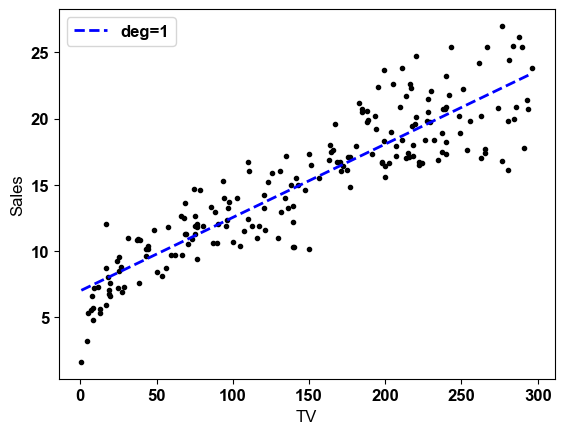

In [89]:
plt.plot(X, y, "k.")
# plt.plot(X, y_predicted, 'r.', label='predicted')
plt.plot(ax_x, ax_y, 'b--', lw=2, label=f'deg={deg_}')
plt.xlabel('TV')
plt.ylabel('Sales')
plt.legend();

In [91]:
if deg_ == 1:
    print(f'\033[1mR-squared\033[0m = {poly_reg_model.score(X.reshape(-1,1), y):.4f}')

R-squared = 0.8122


In [93]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_true=y, y_pred=y_predicted)
print(f'\033[1mMSE\033[0m (scikit-learn) = {mse:.4f}')

MSE (scikit-learn) = 5.2177


In [95]:
print(f'\033[1mMSE\033[0m (user-defined) = {losses[-1]:.4f}')

MSE (user-defined) = 5.2177
